# Generalised ESD Test for Multiple Outliers

The **Generalised Extreme Studentised Deviate (ESD) test** detects up to r outliers in approximately normal data. Unlike the Tietjen-Moore test, you only need to specify the *maximum* possible number of outliers r, not the exact count.

| Property | Value |
|---|---|
| **H₀** | No outliers among the r most extreme values |
| **H₁** | At least one of the r candidates is an outlier |
| **Procedure** | Sequentially remove most extreme, compute G_i, compare to λᵢ |
| **Critical values** | λᵢ from t-distribution with adjusted α |
| **Advantage** | No need to specify exact k; handles masking |
| **Assumption** | Approximately normal data |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

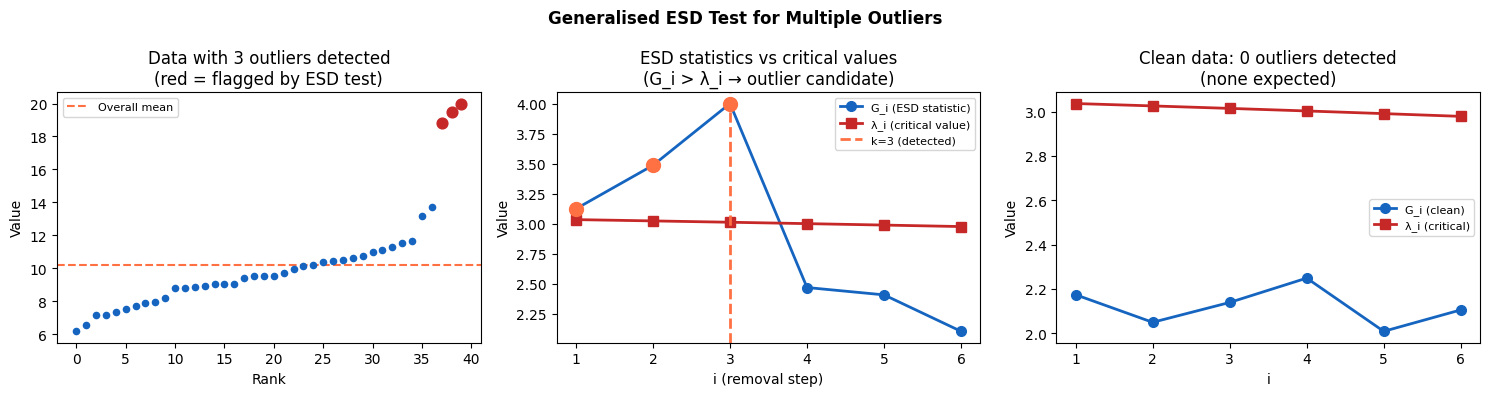

ESD test results (contaminated data):
  i      G_i      λ_i  Outlier val  Reject?
  1   3.1261   3.0361      20.0000     True
  2   3.4886   3.0253      19.5000     True
  3   4.0036   3.0141      18.8000     True
  4   2.4702   3.0026      13.7046    False
  5   2.4089   2.9906      13.1584    False
  6   2.1050   2.9782       6.1734    False
Number of outliers detected: 3


In [2]:
def esd_test(data, r_max, alpha=0.05):
    n = len(data)
    results = []
    x = data.copy()
    for i in range(1, r_max+1):
        mean_i = x.mean(); std_i = x.std(ddof=1)
        G_i = np.max(np.abs(x - mean_i)) / std_i
        # Critical value from t distribution
        p = 1 - alpha / (2*(n-i+1))
        t_crit = stats.t.ppf(p, df=n-i-1)
        lam_i = ((n-i) * t_crit) / np.sqrt((n-i-1+t_crit**2) * (n-i+1))
        outlier_idx = np.argmax(np.abs(x - mean_i))
        outlier_val = x[outlier_idx]
        results.append((i, G_i, lam_i, outlier_val, G_i > lam_i))
        x = np.delete(x, outlier_idx)
    # Determine number of outliers: largest i where G_i > lambda_i
    n_outliers = 0
    for i, G_i, lam_i, val, reject in results:
        if reject:
            n_outliers = i
    return results, n_outliers

np.random.seed(42)
n = 40
base = np.random.normal(10, 2, n)
data_out = base.copy()
data_out[3] = 20.0; data_out[37] = 19.5; data_out[20] = 18.8

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Generalised ESD Test for Multiple Outliers', fontsize=12, fontweight='bold')

r_max = 6
results, n_detected = esd_test(data_out, r_max)

# Panel 1: data with detected outliers marked
sorted_d = np.sort(data_out)
outlier_vals = [r[3] for r in results if r[4]][:n_detected]
colors = ['#C62828' if v in outlier_vals else '#1565C0' for v in sorted_d]
for i, (v, c) in enumerate(zip(sorted_d, colors)):
    axes[0].scatter(i, v, color=c, s=60 if c=='#C62828' else 20, zorder=3)
axes[0].axhline(data_out.mean(), color='#FF7043', lw=1.5, ls='--', label=f'Overall mean')
axes[0].set_title(f'Data with {n_detected} outliers detected\n(red = flagged by ESD test)')
axes[0].set_xlabel('Rank'); axes[0].set_ylabel('Value')
axes[0].legend(fontsize=8)

# Panel 2: G_i vs lambda_i
i_vals  = [r[0] for r in results]
G_vals  = [r[1] for r in results]
lam_vals = [r[2] for r in results]
axes[1].plot(i_vals, G_vals,   'o-', color='#1565C0', lw=2, ms=7, label='G_i (ESD statistic)')
axes[1].plot(i_vals, lam_vals, 's-', color='#C62828', lw=2, ms=7, label='λ_i (critical value)')
for r in results:
    if r[4]:
        axes[1].scatter(r[0], r[1], color='#FF7043', s=100, zorder=4)
axes[1].axvline(n_detected, color='#FF7043', lw=2, ls='--', label=f'k={n_detected} (detected)')
axes[1].set_title('ESD statistics vs critical values\n(G_i > λ_i → outlier candidate)')
axes[1].set_xlabel('i (removal step)'); axes[1].set_ylabel('Value')
axes[1].legend(fontsize=8)

# Panel 3: compare with clean data
results_clean, n_clean = esd_test(base, r_max)
G_clean = [r[1] for r in results_clean]
lam_clean = [r[2] for r in results_clean]
axes[2].plot(i_vals, G_clean, 'o-', color='#1565C0', lw=2, ms=7, label='G_i (clean)')
axes[2].plot(i_vals, lam_clean, 's-', color='#C62828', lw=2, ms=7, label='λ_i (critical)')
axes[2].set_title(f'Clean data: {n_clean} outliers detected\n(none expected)')
axes[2].set_xlabel('i'); axes[2].set_ylabel('Value')
axes[2].legend(fontsize=8)

plt.tight_layout(); plt.show()
print('ESD test results (contaminated data):')
print(f"{'i':>3} {'G_i':>8} {'λ_i':>8} {'Outlier val':>12} {'Reject?':>8}")
for i, G_i, lam_i, val, reject in results:
    print(f'{i:>3} {G_i:>8.4f} {lam_i:>8.4f} {val:>12.4f} {str(reject):>8}')
print(f'Number of outliers detected: {n_detected}')

## Key Takeaways

| | |
|---|---|
| **Specify r_max not k** | Set r_max conservatively high — test finds the actual count |
| **Sequential removal** | Removes most extreme, recomputes G; avoids masking |
| **Decision rule** | Largest i where G_i > λ_i determines the outlier count |
| **λ_i adjustment** | Critical value increases as i grows — Bonferroni-style correction |
| **vs Tietjen-Moore** | ESD preferred when exact k is unknown |
| **Normal assumption** | Non-robust to heavy tails — use domain knowledge alongside |